<a href="https://colab.research.google.com/github/AntoninaStadnik/ITStep-AI/blob/superwised_learning/Practice_Overfitting_%D1%82%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D1%96_%D0%BC%D1%81%D0%B0_%D0%BC%D1%81%D0%B5_%D1%802.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/car_price.csv")

In [3]:
df.head()

,mileage,age,engine,horsepower,num_previous_owners,price
0,60675,4,1.6,228,1,18421
1,23671,24,1.7,179,1,11279
2,82893,5,2.3,115,1,10279
3,94692,11,2.4,94,1,9876
4,12509,9,1.8,126,0,19428


# Опис даних

- **mileage** — пробіг автомобіля в кілометрах
- **age** — вік автомобіля в роках
- **engine** — об'єм двигуна автомобіля в літрах
- **horsepower** — потужність двигуна в кінських силах
- **num_previous_owners** — кількість попередніх власників автомобіля
- **price** — ціна автомобіля

Потрібно спрогнозувати **ціну** автомобіля

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4760 entries, 0 to 4759
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mileage              4760 non-null   int64  
 1   age                  4760 non-null   int64  
 2   engine               4760 non-null   float64
 3   horsepower           4760 non-null   int64  
 4   num_previous_owners  4760 non-null   int64  
 5   price                4760 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 223.3 KB


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

In [9]:
y = df['price']
X = df.drop('price', axis= 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3808, 5)
(952, 5)


#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [10]:
model_tree = DecisionTreeRegressor()
model_tree.fit(X_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте ціну автомобіля для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [15]:
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score

pred = model_tree.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")


MAE: 3058.4884453781515
MSE: 14666721.893907564
R2: 0.5292183907307951


# Завдання 5
Спронозуйте ціну автомобіля для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [18]:
pred = model_tree.predict(X_train)

mae = mean_absolute_error(y_train, pred)
mse = mean_squared_error(y_train, pred)
r2 = r2_score(y_train, pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")

MAE: 0.0
MSE: 0.0
R2: 1.0


In [33]:
pred = model_tree.predict(X_test)

print("pred shape:", pred.shape)




pred shape: (952,)


In [34]:
comparison = pd.DataFrame({
    "Real price": y_test.values,
    "Predicted price": pred
})

print(comparison)


     Real price  Predicted price
0         17465          11901.0
1         13450          22056.0
2         16224          14259.0
3         16753          23694.0
4         30033          31121.0
..          ...              ...
947       28360          21916.0
948       19553          21912.0
949       16377          14728.0
950       16684          12624.0
951       22150          21008.0

[952 rows x 2 columns]


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [27]:
max_depths = range(1, 14)

train_errors = []
test_errors = []

for depth in max_depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_errors.append(mean_absolute_error(y_train, train_pred))
    test_errors.append(mean_absolute_error(y_test, test_pred))

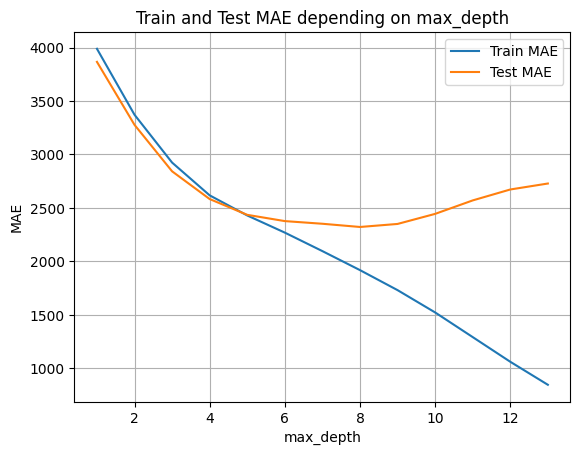

In [29]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_errors, label="Train MAE")
plt.plot(max_depths, test_errors, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

In [ ]:
6

# Завдання 8
Побудуйте такіж графіки для метрик MSE та R2

In [35]:
max_depths = range(1, 14)

train_errors = []
test_errors = []

for depth in max_depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

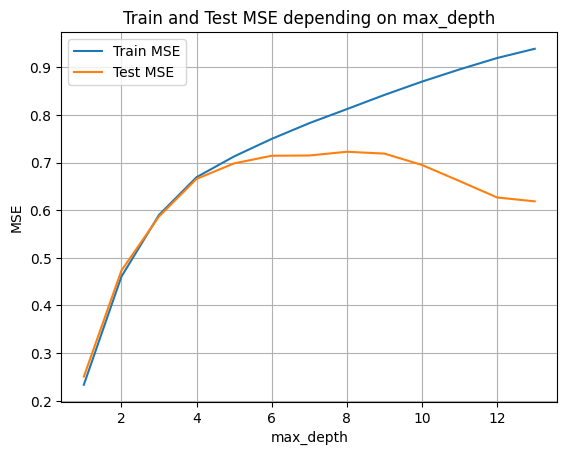

In [40]:
plt.plot(max_depths, train_errors, label="Train MSE")
plt.plot(max_depths, test_errors, label="Test MSE")

plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Train and Test MSE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

In [37]:
max_depths = range(1, 14)

train_errors = []
test_errors = []

for depth in max_depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_errors.append(r2_score(y_train, train_pred))
    test_errors.append(r2_score(y_test, test_pred))

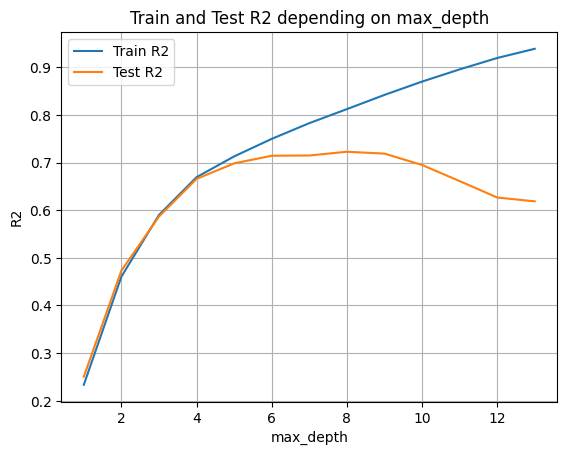

In [39]:
plt.plot(max_depths, train_errors, label="Train R2")
plt.plot(max_depths, test_errors, label="Test R2")

plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("Train and Test R2 depending on max_depth")
plt.legend()
plt.grid()

plt.show()